In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("../data/delhi_ncr_aqi_dataset.csv")

print(df.shape)
df.head()

(201664, 25)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [57]:
df.info()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

CONVERTING THE DATETIME AND DATE COLUMN FROM OBJECT INTO DATETIME FORMAT 

In [58]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("datetime").reset_index(drop=True)

# Filter Delhi only
df = df[df["city"] == "Delhi"].copy()
df = df.sort_values("datetime").reset_index(drop=True)

In [59]:
df = df.drop(columns=["aqi_category", "station", "city"])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122752 entries, 0 to 122751
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   datetime     122752 non-null  datetime64[ns]
 1   date         122752 non-null  datetime64[ns]
 2   year         122752 non-null  int64         
 3   month        122752 non-null  int64         
 4   day          122752 non-null  int64         
 5   hour         122752 non-null  int64         
 6   day_of_week  122752 non-null  object        
 7   is_weekend   122752 non-null  int64         
 8   season       122752 non-null  object        
 9   latitude     122752 non-null  float64       
 10  longitude    122752 non-null  float64       
 11  pm25         122752 non-null  float64       
 12  pm10         122752 non-null  float64       
 13  no2          122752 non-null  float64       
 14  so2          122752 non-null  float64       
 15  co           122752 non-null  floa

In [61]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.weekday

In [62]:
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]

for lag in lags:
    df[f"AQI_lag_{lag}"] = df["aqi"].shift(lag)

df["AQI_diff_1"] = df["aqi"] - df["AQI_lag_1"]
df["AQI_diff_24"] = df["aqi"] - df["AQI_lag_24"]

df["AQI_pct_change_1"] = df["aqi"].pct_change(1)
df["AQI_pct_change_24"] = df["aqi"].pct_change(24)

In [63]:
pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]

for col in pollutants:
    for lag in [1, 3, 6]:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

In [64]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dow_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

In [65]:
df["pm25_no2"] = df["pm25"] * df["no2"]
df["pm25_o3"] = df["pm25"] * df["o3"]

In [66]:
df["AQI_roll_3"] = df["aqi"].rolling(3).mean().shift(1)
df["AQI_roll_6"] = df["aqi"].rolling(6).mean().shift(1)
df["AQI_roll_12"] = df["aqi"].rolling(12).mean().shift(1)

df["AQI_std_3"] = df["aqi"].rolling(3).std().shift(1)
df["AQI_std_6"] = df["aqi"].rolling(6).std().shift(1)

In [67]:
df = pd.get_dummies(df, columns=["season"], drop_first=True)

In [68]:
df["target_AQI"] = df["aqi"].shift(-1)

In [69]:
df = df.dropna()

In [70]:
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,latitude,longitude,...,pm25_o3,AQI_roll_3,AQI_roll_6,AQI_roll_12,AQI_std_3,AQI_std_6,season_post_monsoon,season_summer,season_winter,target_AQI
168,2020-01-04 06:00:00,2020-01-04,2020,1,4,6,Saturday,1,28.6999,77.1653,...,4468.80,494.0,497.0,494.916667,10.392305,7.348469,False,False,True,500.0
169,2020-01-04 06:00:00,2020-01-04,2020,1,4,6,Saturday,1,28.7299,77.1718,...,5922.75,494.0,497.0,496.000000,10.392305,7.348469,False,False,True,500.0
170,2020-01-04 06:00:00,2020-01-04,2020,1,4,6,Saturday,1,28.7762,77.0510,...,5613.93,494.0,497.0,496.000000,10.392305,7.348469,False,False,True,500.0
171,2020-01-04 06:00:00,2020-01-04,2020,1,4,6,Saturday,1,28.6469,77.3164,...,5302.88,500.0,497.0,496.000000,0.000000,7.348469,False,False,True,430.0
172,2020-01-04 06:00:00,2020-01-04,2020,1,4,6,Saturday,1,28.6362,77.2010,...,5150.11,500.0,497.0,496.000000,0.000000,7.348469,False,False,True,500.0


In [71]:
X = df.drop(columns=["datetime", "aqi", "target_AQI", "date","day_of_week"])
y = df["target_AQI"]

In [72]:
print("Object columns:", X.select_dtypes(include=["object"]).columns)
print("Null values:", X.isnull().sum().sum())

Object columns: Index([], dtype='object')
Null values: 0


In [85]:
X.head()

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,...,pm25_no2,pm25_o3,AQI_roll_3,AQI_roll_6,AQI_roll_12,AQI_std_3,AQI_std_6,season_post_monsoon,season_summer,season_winter
168,2020,1,4,6,1,28.6999,77.1653,336.0,583.6,101.5,...,34104.00,4468.80,494.0,497.0,494.916667,10.392305,7.348469,False,False,True
169,2020,1,4,6,1,28.7299,77.1718,397.5,872.9,135.8,...,53980.50,5922.75,494.0,497.0,496.000000,10.392305,7.348469,False,False,True
170,2020,1,4,6,1,28.7762,77.0510,381.9,721.7,121.3,...,46324.47,5613.93,494.0,497.0,496.000000,10.392305,7.348469,False,False,True
171,2020,1,4,6,1,28.6469,77.3164,404.8,832.7,125.2,...,50680.96,5302.88,500.0,497.0,496.000000,0.000000,7.348469,False,False,True
172,2020,1,4,6,1,28.6362,77.2010,253.7,454.0,75.7,...,19205.09,5150.11,500.0,497.0,496.000000,0.000000,7.348469,False,False,True


In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [74]:
split = int(len(df) * 0.8)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y_scaled[:split]
y_test = y_scaled[split:]

Using past 24 hours to predict next hour

In [75]:
SEQ_LEN = 48
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train, y_train, SEQ_LEN)
X_test,  y_test  = create_sequences(X_test,  y_test,  SEQ_LEN)

In [76]:
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

# Check no NaNs
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())

# Check scale range
print("X min/max:", X_train.min(), X_train.max())
print("y min/max:", y_train.min(), y_train.max())

X_train: (98018, 48, 65)
X_test:  (24469, 48, 65)
y_train: (98018, 1)
y_test:  (24469, 1)
NaNs in X_train: 0
NaNs in y_train: 0
X min/max: 0.0 1.0000000000000002
y min/max: 0.0 1.0


In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization,Bidirectional
from tensorflow.keras.optimizers import Adam

In [78]:
model = Sequential([

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(SEQ_LEN, n_features)),
    BatchNormalization(),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
model.summary()

E:\Rasengan\Sem4\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 48, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 48, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,689 (1.37 MB)

 Trainable params: 358,497 (1.37 MB)

 Non-trainable params: 192 (768.00 B)

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    TensorBoard(log_dir='./logs')
]

In [80]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0197 - mae: 0.0943
Epoch 1: val_loss improved from None to 0.00691, saving model to best_model.keras
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - loss: 0.0103 - mae: 0.0760 - val_loss: 0.0069 - val_mae: 0.0611 - learning_rate: 5.0000e-04
Epoch 2/50
2756/2757 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0068 - mae: 0.0642
Epoch 2: val_loss improved from 0.00691 to 0.00469, saving model to best_model.keras
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 56s 20ms/step - loss: 0.0066 - mae: 0.0633 - val_loss: 0.0047 - val_mae: 0.0540 - learning_rate: 5.0000e-04
Epoch 3/50
2755/2757 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0062 - mae: 0.0607
Epoch 3: val_loss improved from 0.00469 to 0.00444, saving model to best_model.keras
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 72s 26ms/step - loss: 0.0061 - mae: 0.0603 - val_loss: 0.0044 - val_mae: 0.0527 - learning_rate: 5.0000e-04
Epoch 4/50
2756/2757 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0059 - mae: 0.

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test)

y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
MAE  : 24.4799
RMSE : 31.6282
R2   : 0.9687


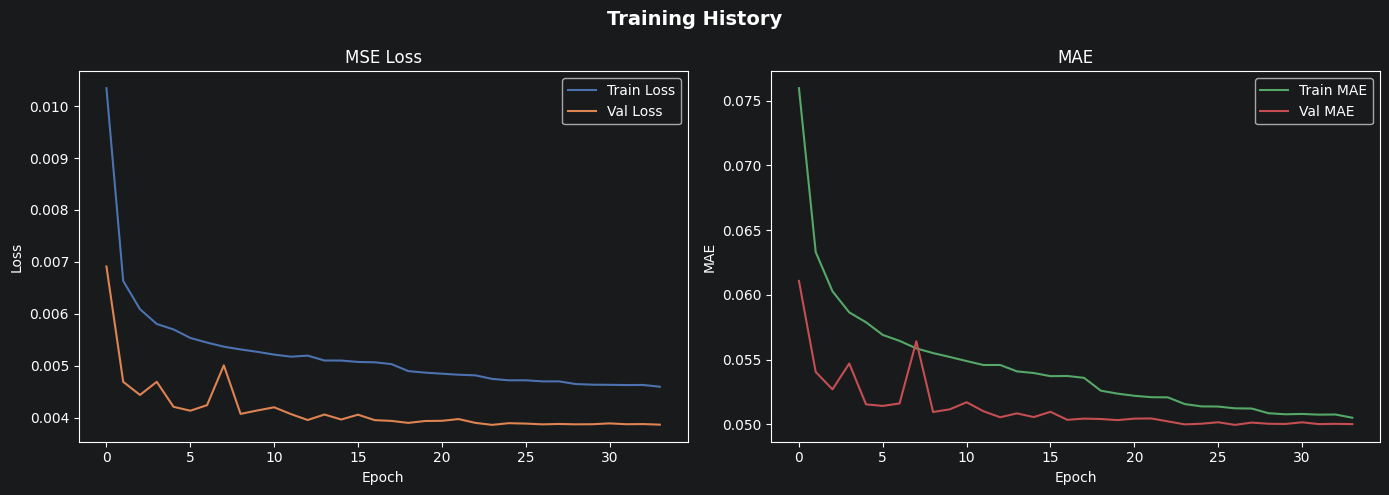

In [84]:
# ── Training History Metrics Plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history['loss'],     label='Train Loss', color='#4C72B0')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#DD8452')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='#55A868')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#C44E52')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()